In [2]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [3]:
import glob
import xarray as xr

PATH = "/Users/lb962/Documents/GitHub/ESL/data/ml_ready/*.nc"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]


File 0: /Users/lb962/Documents/GitHub/ESL/data/ml_ready/small_ds.nc
<xarray.Dataset>
Dimensions:            (station: 9, valid_time: 750192)
Coordinates:
  * station            (station) int64 1 2 3 4 5 6 7 8 10
  * valid_time         (valid_time) datetime64[ns] 1940-01-01 ... 2025-07-30T...
    latitude           float64 ...
    longitude          float64 ...
    station_latitude   (station) float64 ...
    station_longitude  (station) float64 ...
Data variables: (12/14)
    u10                (station, valid_time) float32 ...
    v10                (station, valid_time) float32 ...
    d2m                (station, valid_time) float32 ...
    t2m                (station, valid_time) float32 ...
    msl                (station, valid_time) float32 ...
    sst                (station, valid_time) float32 ...
    ...                 ...
    mwd                (station, valid_time) float32 ...
    mwp                (station, valid_time) float32 ...
    swh                (station, valid_

In [4]:
from numba import njit
import numpy as np
import xarray as xr
from numba import njit

@njit(cache=True, fastmath=True)
def _mask_1d(values, k_eff, mean, std, safe_lo, safe_hi,
             hard_clip_eff, p95, p95_margin_eff,
             q1, q3, use_quantiles, iqr_mult):
    n = values.shape[0]
    dev = np.zeros(n, dtype=np.bool_)
    last_kept = np.nan; have_last=False; prev_was_kept=False
    z_enabled = np.isfinite(std) and std > 0.0
    p95_gate = p95 + p95_margin_eff if np.isfinite(p95) else np.inf
    iqr = q3 - q1
    lo_iqr = q1 - iqr_mult * iqr
    hi_iqr = q3 + iqr_mult * iqr
    for i in range(n):
        x = values[i]
        if not np.isfinite(x): dev[i]=True; prev_was_kept=False; continue
        if np.abs(x) > hard_clip_eff: dev[i]=True; prev_was_kept=False; continue
        if (x >= safe_lo) and (x <= safe_hi): dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True; continue
        if use_quantiles and ((x < lo_iqr) or (x > hi_iqr)): dev[i]=True; prev_was_kept=False; continue
        if z_enabled:
            z = (x - mean) / std
            if np.abs(z) > k_eff: dev[i]=True; prev_was_kept=False; continue
        if not prev_was_kept:
            if x <= p95_gate: dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True
            else: dev[i]=True; prev_was_kept=False
            continue
        if have_last:
            allowed = 1.5 if (-1.0 <= last_kept <= 1.0) else 0.5
            if np.abs(x - last_kept) > allowed: dev[i]=True; prev_was_kept=False; continue
        dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True
    return dev

# FAST block-drift mask: EW-quantile (median) + run-length
@njit(cache=True, fastmath=True)
def _block_mask_1d(values, med_thresh, min_run, alpha):
    n = values.shape[0]
    block = np.zeros(n, dtype=np.bool_)
    m = 0.0                        # EW median estimate (starts near 0 for residuals)
    run = 0                        # consecutive samples with |m| > threshold
    for i in range(n):
        x = values[i]
        if np.isfinite(x):
            # Robbins–Monro quantile update (tau=0.5 -> median)
            m += alpha * (0.5 - (1.0 if x < m else 0.0))
            if np.abs(m) > med_thresh:
                run += 1
                if run == min_run:
                    # backfill the initial block once threshold run is reached
                    start = i - min_run + 1
                    for j in range(start, i + 1):
                        block[j] = True
                elif run > min_run:
                    block[i] = True
            else:
                run = 0
        else:
            run = 0  # NaN breaks the block
    return block
@njit(cache=True, fastmath=True)
def _yrmean_block_mask_1d(values, yr_mean_vals, good_year_vals,
                          mean_abs_thresh, band, min_run):
    """
    Flag contiguous runs that stay near the (shifted) yearly mean, but only
    in years where |yearly mean| > mean_abs_thresh and coverage was 'good'.
    """
    n = values.shape[0]
    block = np.zeros(n, dtype=np.bool_)
    run = 0
    start = 0
    for i in range(n):
        x = values[i]
        if not np.isfinite(x):
            run = 0
            continue

        if not good_year_vals[i]:
            # year not eligible: reset run
            run = 0
            continue

        ymean = yr_mean_vals[i]
        if not np.isfinite(ymean) or (np.abs(ymean) <= mean_abs_thresh):
            # yearly mean not "shifted" enough
            run = 0
            continue

        # Are we "near" the shifted yearly mean?
        if np.abs(x - ymean) <= band:
            if run == 0:
                start = i
            run += 1
            if run == min_run:
                for j in range(start, i + 1):
                    block[j] = True
            elif run > min_run:
                block[i] = True
        else:
            run = 0
    return block
def filter_residual(
    ds: xr.Dataset,
    var: str = "residual",
    dim: str | None = None,
    base_k: float = 5.0,
    safe_keep_band: tuple[float, float] = (-2.0, 2.0),
    hard_clip: float = 3.0,
    p95_margin: float = 0.5,
    station_dim: str = "station",
    min_frac_year: float = 0.5,
    kurt_hard: float = 1.0,
    # mean-shift block knobs
    year_mean_abs_thresh: float = 1.0,   # consider a year "shifted" if |year mean| > 1 m
    block_band: float = 0.5,             # samples within ±band of the yearly mean count toward a block
    min_run: int = 60,                   # consecutive samples near the mean to declare a block
):
    da = ds[var]; dim = da.dims[0] if dim is None else dim
    ds = ds.sortby(dim); da = ds[var].astype("float64")

    # --- robust stats (unchanged)
    mu   = da.mean(dim=dim, skipna=True)
    sig  = da.std(dim=dim,  skipna=True)
    p95  = da.quantile(0.95, dim=dim, skipna=True)
    qs   = da.quantile([0.25, 0.75], dim=dim, skipna=True)
    q1, q3 = qs.sel(quantile=0.25), qs.sel(quantile=0.75)

    m2 = da.var(dim=dim, skipna=True)
    m4 = ((da - mu) ** 4).mean(dim=dim, skipna=True)
    ex_kurt = xr.where(m2 > 0, m4 / (m2 ** 2) - 3.0, 0.0)
    heavy = ex_kurt > kurt_hard

    k_eff          = xr.where(heavy, base_k / 2.5, base_k)
    iqr_mult       = xr.where(heavy, 1.0, 1.5)
    hard_clip_eff  = xr.where(heavy, 2.0, hard_clip)
    p95_margin_eff = xr.where(heavy, 0.1, p95_margin)
    use_quantiles  = heavy

    dev_point = xr.apply_ufunc(
        _mask_1d,
        da, k_eff, mu, sig,
        xr.DataArray(safe_keep_band[0]), xr.DataArray(safe_keep_band[1]),
        hard_clip_eff, p95, p95_margin_eff,
        q1, q3, use_quantiles, iqr_mult,
        input_core_dims=[[dim], [], [], [], [], [], [], [], [], [], [], [], []],
        output_core_dims=[[dim]],
        vectorize=True, dask="parallelized",
        output_dtypes=[bool],
    )

    # --- yearly mean and coverage (unchanged)
    present = da.notnull()
    cov_year = present.groupby(f"{dim}.year").mean(dim=dim)         # fraction present per year
    yr_mean  = da.groupby(f"{dim}.year").mean(dim=dim, skipna=True)  # mean per year
    good_year = cov_year > min_frac_year

    # --- NEW: broadcast per-year values back to each timestamp by selecting with a per-sample 'year' indexer
    # Ensure time axis is datetime64
    if not np.issubdtype(ds[dim].dtype, np.datetime64):
        # If your coord isn't datetime64, convert it here (one-time)
        ds = ds.assign_coords({dim: xr.converters.to_datetime64(ds[dim])})
        da = ds[var].astype("float64")

    year_indexer = xr.DataArray(
        ds[dim].dt.year,         # vector of years for every sample along `dim`
        dims=dim,
        coords={dim: ds[dim]}
    )

    # These now have the SAME dims as `da` (broadcasted back from 'year')
    yr_mean_full   = yr_mean.sel(year=year_indexer)
    good_year_full = good_year.sel(year=year_indexer)

    # --- block detector: runs near the shifted yearly mean
    dev_block = xr.apply_ufunc(
        _yrmean_block_mask_1d,
        da,
        yr_mean_full,
        good_year_full,
        xr.DataArray(year_mean_abs_thresh),
        xr.DataArray(block_band),
        xr.DataArray(np.int64(min_run)),
        input_core_dims=[[dim], [dim], [dim], [], [], []],
        output_core_dims=[[dim]],
        vectorize=True, dask="parallelized",
        output_dtypes=[bool],
    )

    deviant = dev_point | dev_block

    out = ds.copy()
    out[f"{var}_is_deviant"] = deviant
    out[var] = da.where(~deviant)

    if station_dim in out.dims:
        extra = [d for d in cov_year.dims if d not in (station_dim, "year")]
        cov_check = cov_year if not extra else cov_year.mean(dim=extra)
        keep_station = (cov_check > min_frac_year).any(dim="year")
        out = out.isel({station_dim: keep_station})

    return out, out[f"{var}_is_deviant"]
# ds: xr.Dataset with a variable named "residual" along dimension "time"
ds_filtered, dev_mask = filter_residual(ds, var="residual", dim="valid_time")
ds = ds_filtered

In [5]:
def preprocess(ds):
    return ds.sortby("station") 

datasets = [preprocess(xr.open_dataset(f)) for f in files]
ds = xr.concat(datasets, dim="station")

/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


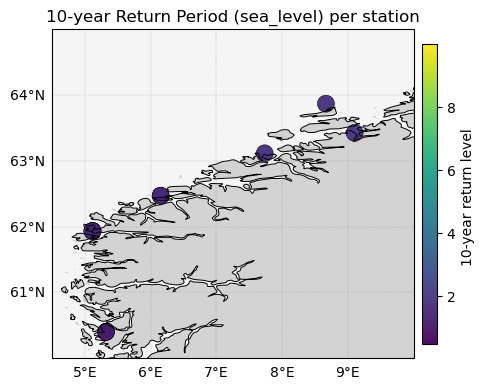

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1) Annual maxima of sea_level per station
annual_max = ds["sea_level"].groupby("valid_time.year").max("valid_time", skipna=True)  # (station, year)

# 2) Require at least 10 annual maxima to estimate a 10-yr RL
n_years = annual_max.notnull().sum("year")                                              # (station,)
tenyr_rl = annual_max.quantile(0.9, dim="year", skipna=True)                             # (station,)
tenyr_rl = tenyr_rl.where(n_years >= 10)                                                # mask weak stations

# 3) Pull station coords (1D over 'station')
lons = ds["station_longitude"].values
lats = ds["station_latitude"].values
vals = tenyr_rl.values

# Optional: units for colorbar label if present
units = ds["sea_level"].attrs.get("units", "")

# 4) Quick Cartopy plot
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(5, 4))
ax = plt.axes(projection=proj)

# Extent with padding from station points
valid = np.isfinite(lons) & np.isfinite(lats)
xmin, xmax = float(np.nanmin(lons[valid])), float(np.nanmax(lons[valid]))
ymin, ymax = float(np.nanmin(lats[valid])), float(np.nanmax(lats[valid]))
pad_x = max(0.5, 0.05 * (xmax - xmin))
pad_y = max(0.5, 0.05 * (ymax - ymin))
ax.set_extent([xmin - pad_x, xmax + pad_x, ymin - pad_y, ymax + pad_y], crs=proj)
ax.set_extent([4.5, 10, 60, 65], crs=proj)

# Base features
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="whitesmoke")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
gl.right_labels = False
gl.top_labels = False

# 5) Plot stations (color = 10-yr return level)
sc = ax.scatter(
    lons, lats,
    c=vals, s=150, cmap="viridis",
    edgecolor="black", linewidth=0.4, alpha=0.95,
    transform=proj
)

cb = plt.colorbar(sc, ax=ax, fraction=0.036, pad=0.02)
cb.set_label(f"10-year return level {f'({units})' if units else ''}")

ax.set_title("10-year Return Period (sea_level) per station")
plt.tight_layout()
plt.show()


In [33]:
import numpy as np
import xarray as xr

# Suppose ds is your Dataset and you want to keep 20% of the time steps
keep_fraction = 0.2

# Number of timesteps
n_time = ds.sizes['valid_time']

# Randomly choose indices to keep
keep_n = int(n_time * keep_fraction)
keep_indices = np.random.choice(n_time, keep_n, replace=False)

# Sort indices to preserve chronological order
keep_indices = np.sort(keep_indices)

# Subset dataset along the time dimension
ds_sub = ds.isel(valid_time=keep_indices)


In [34]:
ds = ds_sub 

In [35]:
# Ensure time is sorted (important for derivatives)
ds = ds.sortby("valid_time")

# --- Core helpers (finite differences over hours) ---
def diff_hours(da, hours: int):
    """Finite-difference derivative over 'hours' (value change per hour)."""
    return (da - da.shift(valid_time=hours)) / hours

# --- Wind features ---
u = ds["u10"]
v = ds["v10"]
wind_speed = np.hypot(u, v).rename("wind_speed")

d_wind_1h = diff_hours(wind_speed, 1).rename("d_wind_1h")   # Δwind / 1h
d_wind_6h = diff_hours(wind_speed, 6).rename("d_wind_6h")   # Δwind / 6h

# --- Pressure derivatives (dsp/dt) ---
sp = ds["sp"]
d_sp_1h = diff_hours(sp, 1).rename("d_sp_1h")
d_sp_6h = diff_hours(sp, 6).rename("d_sp_6h")

# --- Tide shifted features ---
tide_lag1h = ds["tide"].shift(valid_time=1).rename("tide_lag1h")
tide_lag6h = ds["tide"].shift(valid_time=6).rename("tide_lag6h")
tide_lag0h = ds["tide"].shift(valid_time=0).rename("tide_lag0h")

# Make sure sorted
ds = ds.sortby("valid_time")

# Pull just tide to a tidy frame
df = ds[["tide"]].to_dataframe().reset_index()
df = df.sort_values(["station", "valid_time"])

# Compute tidal range per station (across all valid_time)
tide_range = (ds["tide"].max(dim="valid_time") - ds["tide"].min(dim="valid_time"))
tide_range = tide_range.rename("tide_range")

# --- Air density (rho_air) ---
# Use sp (Pa) and t2m (K) if available; else fallback to 1.225 kg/m^3
R_d = 287.05  # J kg^-1 K^-1
if "sp" in ds and "t2m" in ds:
    rho_air = (ds["sp"] / (R_d * ds["t2m"])).astype("float32").rename("rho_air")
else:
    rho_air = xr.zeros_like(wind_speed) + 1.225
    rho_air = rho_air.astype("float32").rename("rho_air")

# --- Drag coefficient C_D (Large & Pond style) ---
U = wind_speed
Cd = xr.where(
    U < 11.0,
    1.14e-3,
    xr.where(U <= 25.0, (0.49 + 0.065 * U) * 1e-3, 2.0e-3)
).astype("float32").rename("Cd")

# --- Wind stress components (N/m^2 = Pa) ---
tau_x = (rho_air * Cd * U * u).astype("float32").rename("tau_x")
tau_y = (rho_air * Cd * U * v).astype("float32").rename("tau_y")
tau_mag = (rho_air * Cd * U**2).astype("float32").rename("tau_mag")

# Optional: tendencies (change over 1h/6h), consistent with your diff_hours helper
tau_d1h = diff_hours(tau_mag, 1).astype("float32").rename("d_tau_1h")
tau_d6h = diff_hours(tau_mag, 6).astype("float32").rename("d_tau_6h")

# --- Assemble into one dataset ---
feat_ds = xr.Dataset(
    {
        "wind_speed": wind_speed,
        "d_wind_1h": d_wind_1h,
        "d_wind_6h": d_wind_6h,
        "d_sp_1h": d_sp_1h,
        "d_sp_6h": d_sp_6h,
        "tide_range_12h": tide_range,
        "tide_lag0h": tide_lag0h,
        "tide_lag1h": tide_lag1h,
        "tide_lag6h": tide_lag6h,
        # "d_msl_1h": d_msl_1h,  # uncomment if you computed these
        # "d_msl_6h": d_msl_6h,
        "tau_x": tau_x,
        "tau_y": tau_y,
        "tau_mag": tau_mag,
        "tau_d1h": tau_d1h,
        "tau_d6h": tau_d6h,
    }
)

# Keep original coordinates/attrs
feat_ds = feat_ds.assign_coords(
    station=ds["station"],
    valid_time=ds["valid_time"]
)
for v in feat_ds.data_vars:
    feat_ds[v].attrs.update(ds[v.split("_")[0]].attrs if v.split("_")[0] in ds.data_vars else {})

# Merge features back with original dataset (optional)
ds_engineered = xr.merge([ds, feat_ds])

In [36]:
# exclude target + sea_level + tide from predictors
predictors = [v for v in ds_engineered.data_vars if v not in ["residual", "sea_level", "tide", "longitude", "latitude", "station_longitude", "station_latitude", "station", "valid_time"]]
target = "residual"
df = ds_engineered[predictors + [target]].to_dataframe().reset_index()
df = df.dropna(subset=[target])

In [37]:
import numpy as np
import pandas as pd

def split_by_return_level_threshold(
    df,
    ds,
    var_name="sea_level",
    lon_name="station_longitude",
    lat_name="station_latitude",
    min_years=10,
    train_frac=0.70,
    val_frac=0.20,
    test_frac=0.10,
    random_state=None,  # optional: shuffle within bands deterministically
):
    """
    Splits stations into train/val/test by sorting their 10-year return level (annual maxima Q0.9):
      - train: lowest return levels (~70% of stations)
      - val  : middle (~20%)
      - test : highest (~10%)

    Assumes df['station'] matches ds station indexing (0..n-1 or identical ids).
    Returns train_df, val_df, test_df, and a helper table with per-station RL and split.
    """

    # --- 1) Compute 10-yr return level per station (like your snippet) ---
    annual_max = ds[var_name].groupby("valid_time.year").max("valid_time", skipna=True)   # (station, year)
    n_years = annual_max.notnull().sum("year")                                            # (station,)
    tenyr_rl = annual_max.quantile(0.9, dim="year", skipna=True)                          # (station,)
    tenyr_rl = tenyr_rl.where(n_years >= min_years)                                       # mask weak stations

    # Build a tidy table keyed by station position (0..n-1)
    rl_df = pd.DataFrame({
        "station": np.arange(ds.sizes["station"]),
        "tenyr_rl": np.asarray(tenyr_rl.values, dtype=float),
        # optional: carry coords if helpful later
        "lon": np.asarray(ds[lon_name].values, dtype=float) if lon_name in ds else np.nan,
        "lat": np.asarray(ds[lat_name].values, dtype=float) if lat_name in ds else np.nan,
        "n_years": np.asarray(n_years.values, dtype=int),
    })

    # Keep only stations with a valid RL
    rl_df = rl_df[np.isfinite(rl_df["tenyr_rl"])].copy()
    if rl_df.empty:
        raise ValueError("No stations have a valid 10-year return level (check min_years and data coverage).")

    # --- 2) Sort by return level (ascending => small to large) ---
    rl_df = rl_df.sort_values("tenyr_rl", kind="mergesort").reset_index(drop=True)  # stable sort

    # Optional: shuffle *within* identical values/bands to avoid positional bias
    if random_state is not None:
        rng = np.random.default_rng(random_state)
        # add tiny jitter only for tie-breaking display order (does not change values)
        jitter = rng.uniform(low=0.0, high=1e-12, size=len(rl_df))
        rl_df = rl_df.assign(_jitter=jitter).sort_values(["tenyr_rl", "_jitter"]).drop(columns="_jitter").reset_index(drop=True)

    # --- 3) 70/20/10 split by station count ---
    n = len(rl_df)
    n_train = int(round(train_frac * n))
    n_val   = int(round(val_frac * n))
    n_test  = n - n_train - n_val  # fill the remainder

    # Guard against degenerate tiny sets
    n_train = max(min(n_train, n - 2), 1)
    n_val   = max(min(n_val,   n - n_train - 1), 0)
    n_test  = n - n_train - n_val

    # Index slices: lowest -> train, middle -> val, highest -> test
    train_stations = rl_df.iloc[:n_train]["station"].to_numpy()
    val_stations   = rl_df.iloc[n_train:n_train + n_val]["station"].to_numpy()
    test_stations  = rl_df.iloc[n_train + n_val:]["station"].to_numpy()

    # Thresholds (for reporting)
    thr_train_max = rl_df.iloc[n_train - 1]["tenyr_rl"] if n_train > 0 else np.nan
    thr_val_max   = rl_df.iloc[n_train + n_val - 1]["tenyr_rl"] if n_val > 0 else np.nan
    thr_test_min  = rl_df.iloc[n_train + n_val]["tenyr_rl"] if n_test > 0 else np.nan

    # Annotate split for the helper table
    split_labels = np.array(["train"] * n_train + ["val"] * n_val + ["test"] * n_test)
    rl_df = rl_df.assign(split=split_labels)

    # --- 4) Slice the master dataframe (station-level disjoint) ---
    m_train = df["station"].isin(train_stations)
    m_val   = df["station"].isin(val_stations)
    m_test  = df["station"].isin(test_stations)

    train_df = df.loc[m_train].copy()
    val_df   = df.loc[m_val].copy()
    test_df  = df.loc[m_test].copy()

    # --- 5) Quick report ---
    print(f"Stations with valid 10-yr RL: {n}")
    print(f"Split counts (stations): train/val/test = {len(train_stations)}/{len(val_stations)}/{len(test_stations)}")
    print(f"Train max RL (cut @ 70%): {thr_train_max}")
    if n_val > 0:
        print(f"Val   max RL (cut @ 90%): {thr_val_max}")
    if n_test > 0:
        print(f"Test  min RL (top 10%):   {thr_test_min}")

    return train_df, val_df, test_df, rl_df

# ---- Usage ----
train_df, val_df, test_df, rl_table = split_by_return_level_threshold(
    df, ds, var_name="sea_level", min_years=10, random_state=42
)


Stations with valid 10-yr RL: 169
Split counts (stations): train/val/test = 118/34/17
Train max RL (cut @ 70%): 3.0061190605163572
Val   max RL (cut @ 90%): 5.008784580230713
Test  min RL (top 10%):   5.0440826416015625


/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


In [ ]:
TARGET = "residual"
EXCLUDE = {"station", "valid_time", "latitude", "longitude", "station_latitude", "station_longitude", TARGET}

predictors = [c for c in df.columns if c not in EXCLUDE]
print(f"{len(predictors)} predictors:\n{predictors}")

25 predictors:
['u10', 'v10', 'd2m', 't2m', 'msl', 'sst', 'sp', 'tp', 'mwd', 'mwp', 'swh', 'wind_speed', 'd_wind_1h', 'd_wind_6h', 'd_sp_1h', 'd_sp_6h', 'tide_range_12h', 'tide_lag0h', 'tide_lag1h', 'tide_lag6h', 'tau_x', 'tau_y', 'tau_mag', 'tau_d1h', 'tau_d6h']


In [ ]:
# --- Quick baseline model: train → predict on val/test ---

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Targets
y_train = train_df[TARGET].values
y_val   = val_df[TARGET].values if not val_df.empty else None
y_test  = test_df[TARGET].values if not test_df.empty else None

# Identify feature types
X_train = train_df[predictors]
X_val   = val_df[predictors] if not val_df.empty else None
X_test  = test_df[predictors] if not test_df.empty else None

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in predictors if c not in num_cols]

# Simple preprocessing + fast, solid regressor
numeric_tf = Pipeline([("imputer", SimpleImputer(strategy="median"))])
categoric_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

pre = ColumnTransformer([
    ("num", numeric_tf, num_cols),
    ("cat", categoric_tf, cat_cols),
])

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
)

pipe = Pipeline([
    ("pre", pre),
    ("model", model),
])

# Fit
pipe.fit(X_train, y_train)

def _report(split_name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2   = r2_score(y_true, y_pred)
    print(f"{split_name:>5} | MAE: {mae:.4f}  RMSE: {rmse:.4f}  R²: {r2:.4f}")

# Predict + simple metrics
if X_val is not None:
    val_pred = pipe.predict(X_val)
    _report("VAL", y_val, val_pred)
    val_df = val_df.copy()
    val_df["pred_"+TARGET] = val_pred

if X_test is not None:
    test_pred = pipe.predict(X_test)
    _report("TEST", y_test, test_pred)
    test_df = test_df.copy()
    test_df["pred_"+TARGET] = test_pred

# If you want a single dataframe with predictions, uncomment:
out = pd.concat([
    train_df.assign(split="train"),
    val_df.assign(split="val") if not val_df.empty else None,
    test_df.assign(split="test") if not test_df.empty else None,
    ]).dropna(subset=[TARGET])
out = out[out["split"].notna()]
out.head()

# `pipe` is your ready-to-use model:
y_new = pipe.predict(new_df[predictors])

In [32]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# -------------------------
# 0) Target & predictors
# -------------------------
TARGET = "residual"
EXCLUDE = {"station", "valid_time", "latitude", "longitude", "station_latitude", "station_longitude", TARGET}

predictors = [c for c in df.columns if c not in EXCLUDE]
print(f"{len(predictors)} predictors:\n{predictors}")

# -------------------------
# 1) Ensure we have station-level threshold split
#    (train: ~70% smallest 10-yr RL; val: ~20% middle; test: ~10% largest)
# -------------------------
if "train_df" not in globals() or "val_df" not in globals() or "test_df" not in globals():
    # Uses the function I gave you earlier. If not in scope, paste it above.
    train_df, val_df, test_df, rl_table = split_by_return_level_threshold(
        df, ds, var_name="sea_level", min_years=10, random_state=42
    )

# Drop rows with missing target
train_df = train_df[np.isfinite(train_df[TARGET])]
val_df   = val_df[np.isfinite(val_df[TARGET])]
test_df  = test_df[np.isfinite(test_df[TARGET])]

X_train, y_train = train_df[predictors], train_df[TARGET].to_numpy()
X_val,   y_val   = val_df[predictors],   val_df[TARGET].to_numpy()
X_test,  y_test  = test_df[predictors],  test_df[TARGET].to_numpy()

# -------------------------
# 2) Build model pipeline
#    (median-impute any gaps -> RandomForest)
# -------------------------
RANDOM_SEED = 42

model = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("rf", RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=RANDOM_SEED,
        oob_score=False
    ))
])

# -------------------------
# 3) Fit & evaluate
# -------------------------
model.fit(X_train, y_train)

y_hat_tr = model.predict(X_train)
y_hat_va = model.predict(X_val)
y_hat_te = model.predict(X_test)

print("\nPerformance:")
print(" Train:", stats(y_train, y_hat_tr))
print("   Val:", stats(y_val,   y_hat_va))
print("  Test:", stats(y_test,  y_hat_te))

# -------------------------
# 4) Feature importances (top 15)
# -------------------------
rf = model.named_steps["rf"]
importances = pd.Series(rf.feature_importances_, index=predictors).sort_values(ascending=False)
topk = 15 if len(importances) > 15 else len(importances)
print("\nTop feature importances:")
print(importances.head(topk).round(4))

# Optional: if you want a compact result dict to reuse later
train_results = {
    "model": model,
    "predictors": predictors,
    "metrics": {
        "train": stats(y_train, y_hat_tr),
        "val":   stats(y_val,   y_hat_va),
        "test":  stats(y_test,  y_hat_te),
    },
    "feature_importances": importances
}


25 predictors:
['u10', 'v10', 'd2m', 't2m', 'msl', 'sst', 'sp', 'tp', 'mwd', 'mwp', 'swh', 'wind_speed', 'd_wind_1h', 'd_wind_6h', 'd_sp_1h', 'd_sp_6h', 'tide_range_12h', 'tide_lag0h', 'tide_lag1h', 'tide_lag6h', 'tau_x', 'tau_y', 'tau_mag', 'tau_d1h', 'tau_d6h']


KeyboardInterrupt: 

In [31]:
df.columns

Index(['station', 'valid_time', 'u10', 'v10', 'd2m', 't2m', 'msl', 'sst', 'sp',
       'tp', 'mwd', 'mwp', 'swh', 'wind_speed', 'd_wind_1h', 'd_wind_6h',
       'd_sp_1h', 'd_sp_6h', 'tide_range_12h', 'tide_lag0h', 'tide_lag1h',
       'tide_lag6h', 'tau_x', 'tau_y', 'tau_mag', 'tau_d1h', 'tau_d6h',
       'residual', 'latitude', 'longitude', 'station_latitude',
       'station_longitude'],
      dtype='object')

In [14]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import StratifiedShuffleSplit

# ---- Helpers ----
def mode_with_tiebreak(s):
    c = Counter(s)
    maxc = max(c.values())
    # deterministic tie-break: alphabetical on label
    return sorted([k for k,v in c.items() if v == maxc])[0]

def get_station_labels(df, qq_df=None, station_col="station", label_col="best_dist_label"):
    """
    Returns a dataframe with one row per station: [station, station_label].
    If qq_df is provided, it must already contain station->best_dist_label.
    Otherwise, compute the station's label as the mode within that station in df.
    """
    if qq_df is not None:
        out = (qq_df[[station_col, label_col]]
               .dropna()
               .drop_duplicates(subset=[station_col], keep="first")
               .rename(columns={label_col: "station_label"}))
    else:
        out = (df.groupby(station_col)[label_col]
                 .apply(mode_with_tiebreak)
                 .rename("station_label")
                 .reset_index())
    return out

def stratified_station_split(station_labels_df, train_size=0.7, val_size=0.2, test_size=0.1, random_state=42):
    """
    Balanced station-level split with stratification on station_label.
    Returns sets of station ids for train/val/test.
    """
    assert abs(train_size + val_size + test_size - 1.0) < 1e-6
    stations = station_labels_df["station"].to_numpy()
    labels   = station_labels_df["station_label"].to_numpy()

    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=(val_size+test_size), random_state=random_state)
    tr_idx, tmp_idx = next(sss1.split(stations, labels))
    tr_st = stations[tr_idx]
    tmp   = station_labels_df.iloc[tmp_idx].reset_index(drop=True)

    rel_test = test_size / (val_size + test_size)
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=rel_test, random_state=random_state)
    vl_idx, te_idx = next(sss2.split(tmp["station"].to_numpy(), tmp["station_label"].to_numpy()))
    vl_st = tmp["station"].to_numpy()[vl_idx]
    te_st = tmp["station"].to_numpy()[te_idx]
    return set(tr_st), set(vl_st), set(te_st)

def majority_unbalanced_split(station_labels_df, train_size=0.7, val_size=0.2, test_size=0.1, random_state=42):
    """
    Very unbalanced: prioritize putting the MAJORITY label into TRAIN.
    - Fill TRAIN with as many majority-label stations as needed to get close to 70%.
    - If majority label count < needed for 70%, top up TRAIN with non-majority stations (randomly).
    - VAL/TEST are sampled from the remaining stations (stratified on their labels to keep stability).
    """
    rng = np.random.default_rng(random_state)

    stations = station_labels_df["station"].to_numpy()
    labels   = station_labels_df["station_label"].to_numpy()
    n_total  = len(stations)
    n_train_target = int(round(train_size * n_total))

    # Identify majority label
    label_counts = Counter(labels)
    majority_label, _ = max(label_counts.items(), key=lambda kv: kv[1])

    maj_mask = (labels == majority_label)
    maj_stations = stations[maj_mask]
    nonmaj_stations = stations[~maj_mask]
    nonmaj_labels   = labels[~maj_mask]

    # 1) Put (up to) needed majority stations into TRAIN
    rng.shuffle(maj_stations)
    train_from_maj = maj_stations[:min(len(maj_stations), n_train_target)]
    train_set = set(train_from_maj)

    # 2) If still short of 70%, top up from non-majority
    if len(train_set) < n_train_target:
        need = n_train_target - len(train_set)
        nonmaj_pool = nonmaj_stations.copy()
        rng.shuffle(nonmaj_pool)
        train_set.update(nonmaj_pool[:need])

    # Remaining pool for VAL/TEST
    remaining_mask = ~np.isin(stations, list(train_set))
    rem_stations   = stations[remaining_mask]
    rem_labels     = labels[remaining_mask]

    # Edge case: if nothing remains (extreme imbalance), make empty val/test
    if len(rem_stations) == 0:
        return train_set, set(), set()

    # 3) Split remaining into VAL/TEST (stratified to be stable)
    # Desired counts
    n_val_target  = int(round(val_size * n_total))
    n_test_target = n_total - len(train_set) - n_val_target
    # Convert to relative test size on remaining pool
    if len(rem_stations) > 0:
        rel_test = n_test_target / max(len(rem_stations), 1)
        rel_test = min(max(rel_test, 0.0), 1.0)
    else:
        rel_test = 0.0

    # If not enough samples to stratify cleanly, fall back to random split
    if len(np.unique(rem_labels)) > 1 and 0 < rel_test < 1:
        sss = StratifiedShuffleSplit(n_splits=1, test_size=rel_test, random_state=random_state)
        vl_idx, te_idx = next(sss.split(rem_stations, rem_labels))
        val_set  = set(rem_stations[vl_idx])
        test_set = set(rem_stations[te_idx])
    else:
        # Random fallback
        rem = rem_stations.copy()
        rng.shuffle(rem)
        val_set  = set(rem[:n_val_target])
        test_set = set(rem[n_val_target:])

    return train_set, val_set, test_set

# ---- Build station labels (prefers qq_df if available) ----
# qq_df: expected columns ["station", "best_dist_label"]
station_labels_df = get_station_labels(df, qq_df=qq_df if "qq_df" in globals() else None,
                                       station_col="station", label_col="best_dist_label")

# ---- EXPERIMENT 1: Balanced (all labels roughly equally represented across splits) ----
train_stn_bal, val_stn_bal, test_stn_bal = stratified_station_split(
    station_labels_df, train_size=0.70, val_size=0.20, test_size=0.10, random_state=RANDOM_SEED
)

m_train_bal = df["station"].isin(train_stn_bal)
m_val_bal   = df["station"].isin(val_stn_bal)
m_test_bal  = df["station"].isin(test_stn_bal)

X_train_bal, y_train_bal = df.loc[m_train_bal, predictors], df.loc[m_train_bal, target]
X_val_bal,   y_val_bal   = df.loc[m_val_bal,   predictors], df.loc[m_val_bal,   target]
X_test_bal,  y_test_bal  = df.loc[m_test_bal,  predictors], df.loc[m_test_bal,  target]

# ---- EXPERIMENT 2: Very unbalanced (train dominated by majority label; val/test hold the rest) ----
train_stn_unb, val_stn_unb, test_stn_unb = majority_unbalanced_split(
    station_labels_df, train_size=0.70, val_size=0.20, test_size=0.10, random_state=RANDOM_SEED
)

m_train_unb = df["station"].isin(train_stn_unb)
m_val_unb   = df["station"].isin(val_stn_unb)
m_test_unb  = df["station"].isin(test_stn_unb)

X_train_unb, y_train_unb = df.loc[m_train_unb, predictors], df.loc[m_train_unb, target]
X_val_unb,   y_val_unb   = df.loc[m_val_unb,   predictors], df.loc[m_val_unb,   target]
X_test_unb,  y_test_unb  = df.loc[m_test_unb,  predictors], df.loc[m_test_unb,  target]

# ---- Optional sanity prints ----
def summary(name, st_train, st_val, st_test):
    n_total = len(station_labels_df)
    lbl = station_labels_df.set_index("station")["station_label"]
    def mix(sts):
        return lbl.loc[list(sts)].value_counts(normalize=True).round(3).to_dict() if len(sts)>0 else {}
    print(f"\n{name}")
    print(f"  stations total={n_total}")
    print(f"  train/val/test counts = {len(st_train)}/{len(st_val)}/{len(st_test)} "
          f"(~{len(st_train)/n_total:.2%}/~{len(st_val)/n_total:.2%}/~{len(st_test)/n_total:.2%})")
    print(f"  label mix train: {mix(st_train)}")
    print(f"  label mix val  : {mix(st_val)}")
    print(f"  label mix test : {mix(st_test)}")

summary("EXP 1 (Balanced)", train_stn_bal, val_stn_bal, test_stn_bal)
summary("EXP 2 (Unbalanced)", train_stn_unb, val_stn_unb, test_stn_unb)

# ---- Your existing metrics usage example ----
# model.fit(X_train_bal, y_train_bal)  # etc...
# y_pred_val_bal = model.predict(X_val_bal)
# print(stats(y_val_bal, y_pred_val_bal))


KeyError: 'Column not found: best_dist_label'

In [ ]:
print(nein)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
RANDOM_SEED = 42

def stats(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2   = r2_score(y_true, y_pred)
    denom = np.where(np.abs(y_true) < 1e-8, np.nan, np.abs(y_true))
    mape = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100.0
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE_%": mape}

station_scores = []
X_cols = predictors 

# loop over each station separately
for st in df["station"].unique():
    df_st = df[df["station"] == st].sort_values("valid_time")

    # simple random split: 80% train, 20% test (by time order)
    n = len(df_st)
    n_train = int(0.8 * n)
    train_df, test_df = df_st.iloc[:n_train], df_st.iloc[n_train:]

    X_train, y_train = train_df[X_cols], train_df[target]
    X_test,  y_test  = test_df[X_cols],  test_df[target]

    model = LinearRegression(n_jobs=-1)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    station_scores.append({"station": st, **stats(y_test, y_pred)})

# Summarise
scores_df = pd.DataFrame(station_scores).set_index("station")
print("\n=== Per-station scores (trained & tested on same station) ===")
print(scores_df.to_string(float_format=lambda x: f"{x:.4f}"))

print("\nMean across stations:")
print(scores_df.mean().to_string(float_format=lambda x: f"{x:.4f}"))


=== Per-station scores (trained & tested on same station) ===
           MAE   RMSE     R2   MAPE_%
station                              
1       0.0540 0.0700 0.7372 456.2117
2       0.0564 0.0717 0.7679 350.8232
3       0.1140 0.2307 0.1852 271.5955
4       0.1130 0.1365 0.2884 453.3802
5       0.1314 0.1588 0.2883 750.4112
6       0.1007 0.1959 0.2295 472.0702
7       0.0609 0.0778 0.7333 270.3196
8       0.0562 0.0732 0.6753 277.3322
10      0.1843 0.2183 0.0732 502.8871

Mean across stations:
MAE        0.0968
RMSE       0.1370
R2         0.4420
MAPE_%   422.7812


In [ ]:
scores_df = scores_df.reset_index()

In [ ]:
import pandas as pd
import numpy as np

# --- Extract per-station coordinates from ds ---
station_vals = np.ravel(ds["station"].values)
lat_vals     = np.ravel(ds["station_latitude"].values)
lon_vals     = np.ravel(ds["station_longitude"].values)

coords_df = pd.DataFrame({
    "station": station_vals,
    "lat": lat_vals,
    "lon": lon_vals
}).drop_duplicates("station")

# --- Merge with your scores_df ---
scores_with_coords = (
    scores_df.reset_index()   # bring 'station' back as column
             .merge(coords_df, on="station", how="left")
             .set_index("station")
)

print(scores_with_coords.head())


         index       MAE      RMSE        R2      MAPE_%        lat       lon
station                                                                      
1            0  0.053981  0.069999  0.737160  456.211668  60.155000 -1.140000
2            1  0.056409  0.071694  0.767944  350.823224  61.933000  5.117000
3            2  0.114015  0.230687  0.185173  271.595540  60.154028 -1.140306
4            3  0.113014  0.136469  0.288394  453.380206  60.398046  5.320487
5            4  0.131393  0.158801  0.288350  750.411205  61.933776  5.113310


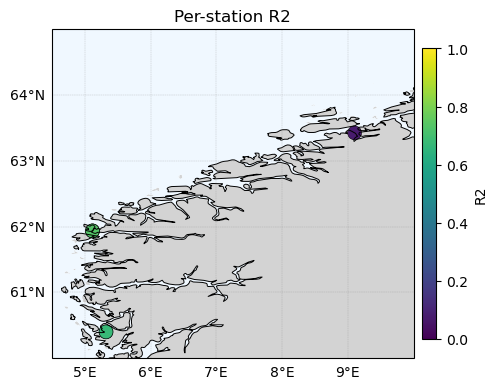

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize

# Choose metric to color by
color_metric = "R2"

# Projection
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(5, 4))
ax = plt.axes(projection=proj)

# Extent with a little padding
xmin, xmax = float(scores_with_coords["lon"].min()), float(scores_with_coords["lon"].max())
ymin, ymax = float(scores_with_coords["lat"].min()), float(scores_with_coords["lat"].max())
pad_x = max(0.5, 0.05 * (xmax - xmin))
pad_y = max(0.5, 0.05 * (ymax - ymin))
ax.set_extent([xmin - pad_x, xmax + pad_x, ymin - pad_y, ymax + pad_y], crs=proj)
ax.set_extent([4.5, 10, 60, 65], crs=proj)

# Base layers
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
gl.right_labels = False
gl.top_labels = False

# Scatter: color = metric, size fixed (or scale by #obs if you want)
norm = Normalize(vmin=min(0, scores_with_coords[color_metric].min()), vmax=1.0)
sc = ax.scatter(
    scores_with_coords["lon"], scores_with_coords["lat"],
    c=scores_with_coords[color_metric],
    s=100, cmap="viridis", norm=norm,
    edgecolor="black", linewidth=0.4, alpha=1,
    transform=proj
)

# Colorbar
cb = plt.colorbar(sc, ax=ax, fraction=0.036, pad=0.02)
cb.set_label(color_metric)

ax.set_title(f"Per-station {color_metric}")
plt.tight_layout()
plt.show()


In [ ]:
qq_dist = pd.read_csv("/Users/lb962/Documents/GitHub/ESL/data/processed/q-qstations.csv")
qq_dist.reset_index()

,index,Unnamed: 0,station_index,lognorm_r2,lognorm_rmse,gamma_r2,gamma_rmse,gev_r2,gev_rmse,fisk_r2,fisk_rmse,burr_r2,burr_rmse,gpd95_r2,gpd95_rmse,best_dist_idx,best_dist_label
0,0,0,0,0.972736,0.015069,0.995834,0.005891,0.998406,0.005309,0.874212,0.032368,0.993497,0.007360,0.923203,0.036842,2.0,gev
1,1,1,1,0.970537,0.017874,0.995450,0.007024,0.998676,0.005355,0.868438,0.037769,0.988447,0.011192,0.704782,0.079969,2.0,gev
2,2,2,2,0.984853,0.015883,0.956114,0.027035,0.967248,0.028466,0.973114,0.021161,0.976736,0.019684,0.696041,0.086719,0.0,lognorm
3,3,3,3,0.981149,0.013892,0.994925,0.007208,0.997521,0.007746,0.905154,0.031162,0.997446,0.005113,0.542123,0.105282,2.0,gev
4,4,4,4,0.976614,0.017949,0.992412,0.010224,0.998850,0.006167,0.893348,0.038331,0.996706,0.006736,0.903030,0.056622,2.0,gev
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,152,152,152,0.989328,0.020477,0.994051,0.015288,0.982696,0.031824,0.905504,0.060932,0.989572,0.020241,0.922379,0.067401,1.0,gamma
153,153,153,153,0.975699,0.035986,0.999369,0.005799,0.985781,0.033915,0.866556,0.084327,0.981197,0.031654,0.935816,0.072056,1.0,gamma
154,154,154,154,0.965684,0.020787,0.996243,0.006878,0.992940,0.013705,0.852703,0.043067,0.984192,0.014109,0.935001,0.041585,1.0,gamma
155,155,155,155,0.984832,0.018947,0.999191,0.004377,0.990585,0.019838,0.897317,0.049299,0.992838,0.013019,0.901330,0.064222,1.0,gamma


In [ ]:
df.station.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8, 10])

In [ ]:
print("hallo")

In [ ]:
def stats(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2   = r2_score(y_true, y_pred)
    denom = np.where(np.abs(y_true) < 1e-8, np.nan, np.abs(y_true))
    mape = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100.0
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE_%": mape}

rng = np.random.default_rng(RANDOM_SEED)
stations = np.array(sorted(df["station"].unique()))
perm = rng.permutation(stations)

n = len(perm)
n_train = int(round(0.70 * n))
n_val   = int(round(0.10 * n))
n_test  = n - n_train - n_val

train_stn = set(perm[:n_train])
val_stn   = set(perm[n_train:n_train + n_val])
test_stn  = set(perm[n_train + n_val:])

m_train = df["station"].isin(train_stn)
m_val   = df["station"].isin(val_stn)
m_test  = df["station"].isin(test_stn)

X_cols = predictors  # all other variables as predictors

X_train, y_train = df.loc[m_train, X_cols], df.loc[m_train, target]
X_val,   y_val   = df.loc[m_val,   X_cols], df.loc[m_val,   target]
X_test,  y_test  = df.loc[m_test,  X_cols], df.loc[m_test,  target]

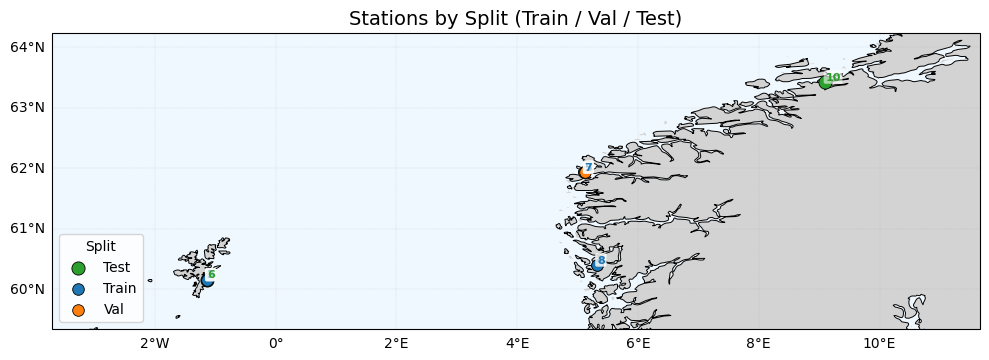

Saved: station_split_map.png


In [ ]:
# pip install cartopy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1) Unique stations with coordinates
st_meta = (
    df[["station", "station_latitude", "station_longitude"]]
    .dropna(subset=["station_latitude", "station_longitude"])
    .drop_duplicates(subset=["station"])
    .sort_values("station")
    .reset_index(drop=True)
)

# 2) Add split label
def split_label(s):
    if s in train_stn: return "train"
    if s in val_stn:   return "val"
    if s in test_stn:  return "test"
    return "unknown"

st_meta["split"] = st_meta["station"].apply(split_label)

# 3) Map setup
lon_min, lon_max = st_meta["station_longitude"].min(), st_meta["station_longitude"].max()
lat_min, lat_max = st_meta["station_latitude"].min(),  st_meta["station_latitude"].max()

# pad the extent a bit
d_lon = (lon_max - lon_min) or 1.0
d_lat = (lat_max - lat_min) or 1.0
pad = 0.25
extent = [lon_min - pad*d_lon, lon_max + pad*d_lon,
          lat_min - pad*d_lat, lat_max + pad*d_lat]

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=proj)
ax.set_extent(extent, crs=proj)

# basemap features
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.6)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle="--")
gl.right_labels = False
gl.top_labels = False

# 4) Plot by split
colors = {"train": "tab:blue", "val": "tab:orange", "test": "tab:green", "unknown": "gray"}
sizes  = {"train": 70, "val": 70, "test": 90, "unknown": 60}  # make test a bit bigger

for split, df_split in st_meta.groupby("split"):
    ax.scatter(
        df_split["station_longitude"], df_split["station_latitude"],
        s=sizes.get(split, 70),
        color=colors.get(split, "gray"),
        edgecolor="k",
        linewidth=0.6,
        transform=proj,
        zorder=5,
        label=split.capitalize()
    )

# 5) Optional: label station IDs
label_points = True
if label_points:
    for _, r in st_meta.iterrows():
        ax.text(
            r["station_longitude"], r["station_latitude"],
            f'{int(r["station"])}',
            transform=proj,
            fontsize=8, weight="bold",
            ha="left", va="bottom",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6),
            zorder=6,
            color=colors.get(r["split"], "black")
        )

# legend & title
handles, labels = ax.get_legend_handles_labels()
# deduplicate legend entries
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc="lower left", title="Split")
plt.title("Stations by Split (Train / Val / Test)", fontsize=14)
plt.tight_layout()
plt.savefig("station_split_map.png", dpi=150)
plt.show()

print("Saved: station_split_map.png")


In [ ]:
# ---------------------------
# 4) Linear model (Ridge) with impute + scale
# ---------------------------
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Pipeline: handle NaNs -> scale -> linear model
model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0, random_state=RANDOM_SEED))
])

model.fit(X_train, y_train)

# ---------------------------
# 5) Evaluate
# ---------------------------
from sklearn.metrics import r2_score, mean_absolute_error

def evaluate(name, X, y, m):
    pred = m.predict(X)
    r2 = r2_score(y, pred)
    mae = mean_absolute_error(y, pred)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return pred

print("Performance:")
_ = evaluate("Train", X_train, y_train, model)
_ = evaluate(" Val ", X_val,   y_val,   model)
test_pred = evaluate("Test ", X_test,  y_test,  model)

# ---------------------------
# 6) Save model + test predictions
# ---------------------------
# import joblib
# joblib.dump({"model": model, "features": X_cols}, "linear_residual_model.joblib")
out = df.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
#out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)

print("Saved: linear_residual_model.joblib")
print("Saved: test_predictions.parquet")

Performance:
Train | R2: 0.4800 | MAE: 0.0858
 Val  | R2: 0.7331 | MAE: 0.0618
Test  | R2: 0.3616 | MAE: 0.1245
Saved: linear_residual_model.joblib
Saved: test_predictions.parquet


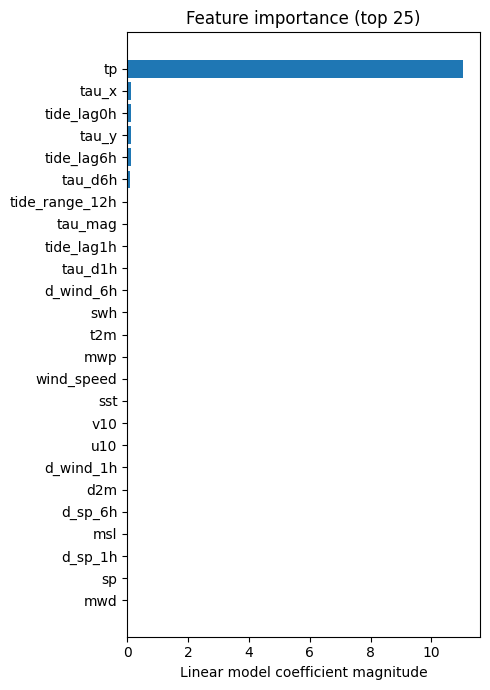

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# If you used a Pipeline as shown earlier:
lin = model.named_steps["ridge"]     # the actual Ridge model
scaler = model.named_steps["scaler"] # the StandardScaler

# Get feature names (must be same order as X_train columns)
feature_names = np.array(X_cols)

# Coefficients are in the scaled space — optionally rescale back to original feature units:
coefs = lin.coef_ / scaler.scale_

# Compute absolute importance
imp = np.abs(coefs)

# Sort and plot top-N
order = np.argsort(imp)[::-1]
top_k = 30
order = order[:top_k]

plt.figure(figsize=(5, max(2, 0.28*len(order))))
plt.barh(feature_names[order][::-1], imp[order][::-1])
plt.xlabel("Linear model coefficient magnitude")
plt.title(f"Feature importance (top {len(order)})")
plt.tight_layout()
plt.show()


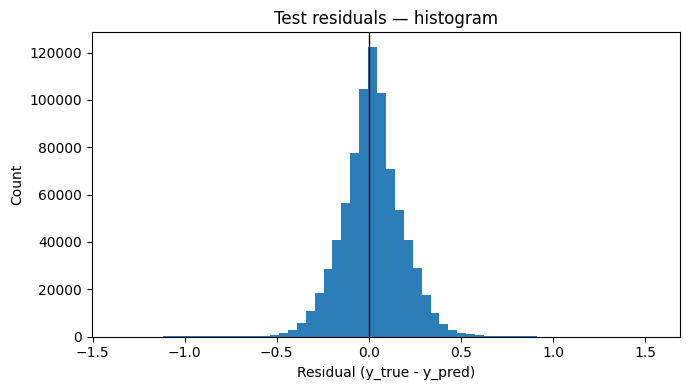

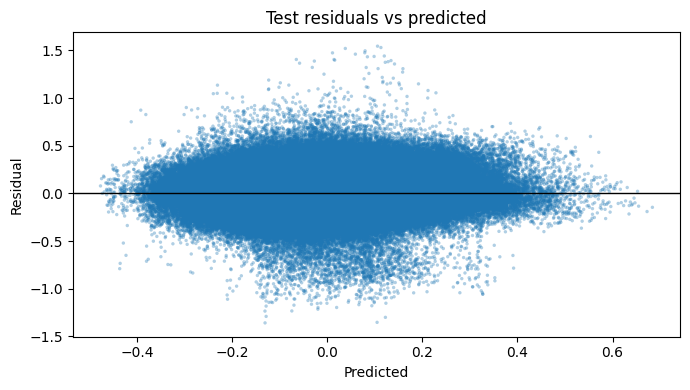

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# If starting fresh, load what you saved:
# out = pd.read_parquet("test_predictions.parquet")

# Make sure the columns are named consistently
preds = out.rename(columns={"residual_pred": "y_pred", target: "y_true"}).copy()
preds["valid_time"] = pd.to_datetime(preds["valid_time"])
preds["residual"] = preds["y_true"] - preds["y_pred"]

# --- A) Residual histogram ---
plt.figure(figsize=(7,4))
plt.hist(preds["residual"].dropna(), bins=60, alpha=0.95)
plt.axvline(0, color="k", lw=1)
plt.xlabel("Residual (y_true - y_pred)")
plt.ylabel("Count")
plt.title("Test residuals — histogram")
plt.tight_layout()
plt.show()

# --- B) Residuals vs Predicted (heteroscedasticity check) ---
plt.figure(figsize=(7,4))
plt.scatter(preds["y_pred"], preds["residual"], s=6, alpha=0.35, edgecolors="none")
plt.axhline(0, color="k", lw=1)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Test residuals vs predicted")
plt.tight_layout()
plt.show()


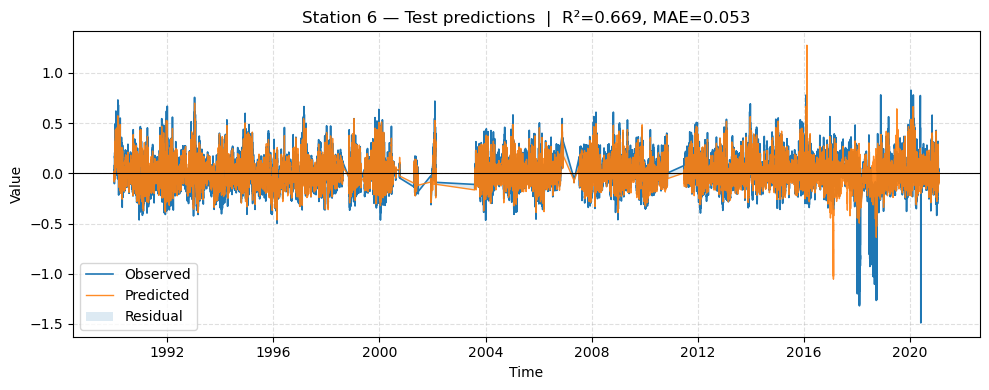

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

def plot_station_residuals(station_id):
    g = preds[preds["station"] == station_id].sort_values("valid_time")
    if g.empty:
        print(f"No test rows for station {station_id}")
        return
    r2  = r2_score(g["y_true"], g["y_pred"])
    mae = mean_absolute_error(g["y_true"], g["y_pred"])

    plt.figure(figsize=(10,4))
    plt.plot(g["valid_time"], g["y_true"], label="Observed", lw=1.2)
    plt.plot(g["valid_time"], g["y_pred"], label="Predicted", lw=1.0, alpha=0.9)
    plt.fill_between(g["valid_time"], g["y_pred"], g["y_true"], alpha=0.15, label="Residual")
    plt.axhline(0, color="k", lw=0.8)
    plt.title(f"Station {station_id} — Test predictions  |  R²={r2:.3f}, MAE={mae:.3f}")
    plt.xlabel("Time"); plt.ylabel("Value"); plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# Example:
plot_station_residuals(preds['station'].iloc[0])


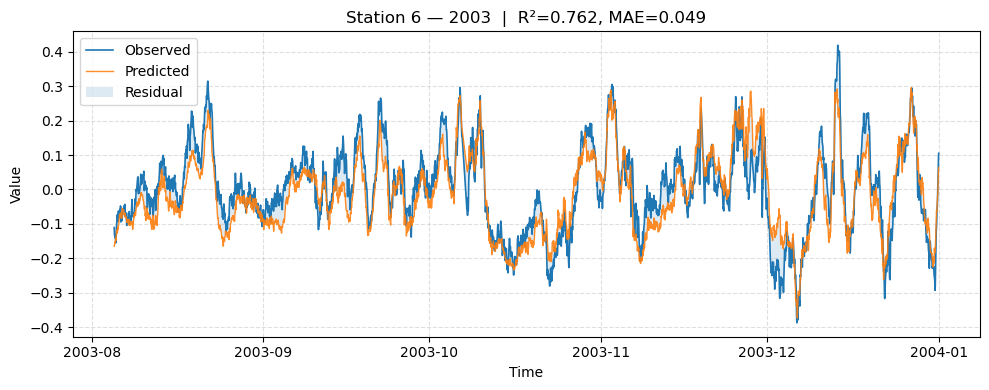

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

def plot_station_residuals(station_id, year=None):
    g = preds[preds["station"] == station_id].sort_values("valid_time").copy()
    if g.empty:
        print(f"No test rows for station {station_id}")
        return
    
    if year is not None:
        g = g[g["valid_time"].dt.year == year]
        if g.empty:
            print(f"No test rows for station {station_id} in year {year}")
            return
    
    r2  = r2_score(g["y_true"], g["y_pred"])
    mae = mean_absolute_error(g["y_true"], g["y_pred"])

    plt.figure(figsize=(10,4))
    plt.plot(g["valid_time"], g["y_true"], label="Observed", lw=1.2)
    plt.plot(g["valid_time"], g["y_pred"], label="Predicted", lw=1.0, alpha=0.9)
    plt.fill_between(g["valid_time"], g["y_pred"], g["y_true"], alpha=0.15, label="Residual")
    plt.title(f"Station {station_id} — {year if year else 'Full period'}  |  R²={r2:.3f}, MAE={mae:.3f}")
    plt.xlabel("Time"); plt.ylabel("Value")
    plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# Example: first station in 2017
plot_station_residuals(preds['station'].iloc[0], year=2003)


In [ ]:
# --- replace your Section 4–6 with this MLP version ---

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd

# 4) MLP model (with impute+scale)
mlp_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler(with_mean=True, with_std=True)),
    ("mlp",     MLPRegressor(
        hidden_layer_sizes=(256, 128, 64),  # try (256,128) or (512,256,128) if you want more capacity
        activation="relu",
        solver="adam",
        alpha=1e-4,              # L2 weight decay
        learning_rate_init=1e-3,
        batch_size=2048,         # tune depending on RAM
        max_iter=200,            # optimizer steps (epochs)
        early_stopping=True,     # uses 10% of TRAIN as internal validation
        n_iter_no_change=15,
        validation_fraction=0.1,
        shuffle=True,
        random_state=RANDOM_SEED,
        verbose=False,
    ))
])

mlp_pipe.fit(X_train, y_train)

# 5) Evaluate
def evaluate(name, X, y, m):
    pred = m.predict(X)
    r2 = r2_score(y, pred)
    mae = mean_absolute_error(y, pred)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return pred

print("Performance (MLP):")
_ = evaluate("Train", X_train, y_train, mlp_pipe)
_ = evaluate(" Val ", X_val,   y_val,   mlp_pipe)
test_pred = evaluate("Test ", X_test,  y_test,  mlp_pipe)

# 6) Save test predictions (same as before)
out = df.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)

print("Saved: test_predictions.parquet")

/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Performance (MLP):


In [ ]:
# pip install tensorflow scikit-learn numpy pandas

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras

# ---------------------------
# 0) Config
# ---------------------------
LOOKBACK = 72          # timesteps per sample (e.g., 72 hours)
BATCH_SIZE = 256
EPOCHS = 40
RANDOM_SEED = 1        # you already set this above
TARGET = target        # "residual"
FEATURES = X_cols      # your predictors (exclude residual/sea_level/tide)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ---------------------------
# 1) Prepare tidy frames (same split you already created)
# ---------------------------
def tidy(df_part):
    # ensure sorted by (station, time)
    return (df_part[["station","valid_time"] + FEATURES + [TARGET]]
            .sort_values(["station","valid_time"])
            .reset_index(drop=True))

train_df = tidy(df.loc[m_train])
val_df   = tidy(df.loc[m_val])
test_df  = tidy(df.loc[m_test])

# ---------------------------
# 2) Impute & scale features (fit on TRAIN stations only)
# ---------------------------
imp = SimpleImputer(strategy="median")
sc  = StandardScaler()

Xtr = imp.fit_transform(train_df[FEATURES])
Xtr = sc.fit_transform(Xtr)

Xva = sc.transform(imp.transform(val_df[FEATURES]))
Xte = sc.transform(imp.transform(test_df[FEATURES]))

ytr = train_df[TARGET].values
yva = val_df[TARGET].values
yte = test_df[TARGET].values

# Keep ids to map predictions back
id_tr = train_df[["station","valid_time"]].values
id_va = val_df[["station","valid_time"]].values
id_te = test_df[["station","valid_time"]].values

# ---------------------------
# 3) Build sequences per station (no cross-station mixing)
# ---------------------------
def make_sequences(X, y, ids, stations, lookback=72):
    """
    X: np.array [n, p]
    y: np.array [n]
    ids: array of [station, timestamp]
    stations: array same length as X of station ids
    returns: X_seq [m, lookback, p], y_seq [m], ids_seq [m, 2]
    """
    X_list, y_list, id_list = [], [], []
    # indices per station in contiguous blocks (data are sorted)
    stn = stations.reshape(-1)
    _, start_idx, counts = np.unique(stn, return_counts=True, return_index=True)
    for s_idx, cnt in zip(start_idx, counts):
        lo, hi = s_idx, s_idx + cnt
        Xi, yi, idi = X[lo:hi], y[lo:hi], ids[lo:hi]
        if len(Xi) < lookback: 
            continue
        # sliding window within this station only
        for t in range(lookback-1, len(Xi)):
            X_list.append(Xi[t-lookback+1:t+1, :])
            y_list.append(yi[t])                 # predict residual at time t
            id_list.append(idi[t])               # (station, valid_time at t)
    if not X_list:
        return (np.empty((0, lookback, X.shape[1]), dtype=np.float32),
                np.empty((0,), dtype=np.float32),
                np.empty((0, 2), dtype=object))
    return (np.asarray(X_list, dtype=np.float32),
            np.asarray(y_list, dtype=np.float32),
            np.asarray(id_list, dtype=object))

# station arrays (sorted already)
st_tr = train_df["station"].values
st_va = val_df["station"].values
st_te = test_df["station"].values

Xtr_seq, ytr_seq, idtr_seq = make_sequences(Xtr, ytr, id_tr, st_tr, LOOKBACK)
Xva_seq, yva_seq, idva_seq = make_sequences(Xva, yva, id_va, st_va, LOOKBACK)
Xte_seq, yte_seq, idte_seq = make_sequences(Xte, yte, id_te, st_te, LOOKBACK)

print(f"Seq shapes -> train: {Xtr_seq.shape}, val: {Xva_seq.shape}, test: {Xte_seq.shape}")

# ---------------------------
# 4) tf.data pipelines
# ---------------------------
def ds_from_arrays(X, y, batch):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    return ds.shuffle(len(X), seed=RANDOM_SEED).batch(batch).prefetch(tf.data.AUTOTUNE)

train_ds = ds_from_arrays(Xtr_seq, ytr_seq, BATCH_SIZE)
val_ds   = tf.data.Dataset.from_tensor_slices((Xva_seq, yva_seq)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((Xte_seq, yte_seq)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# ---------------------------
# 5) LSTM model
# ---------------------------
n_features = Xtr_seq.shape[-1]
inp = keras.Input(shape=(LOOKBACK, n_features))
x = keras.layers.LSTM(128, return_sequences=True)(inp)
x = keras.layers.LSTM(64)(x)
x = keras.layers.Dense(64, activation="relu")(x)
out = keras.layers.Dense(1)(x)

model = keras.Model(inp, out)
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae")

callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
]

history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=1)

# ---------------------------
# 6) Evaluate (MAE / RMSE / R2) and save predictions
# ---------------------------
def evaluate(name, ds, y_true, ids_arr):
    y_pred = model.predict(ds, verbose=0).ravel()
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:>5} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
    pred_df = pd.DataFrame(ids_arr, columns=["station","valid_time"])
    pred_df["valid_time"] = pd.to_datetime(pred_df["valid_time"])
    pred_df["residual"] = y_true
    pred_df["residual_pred"] = y_pred
    return pred_df

print("Performance (LSTM):")
train_pred_df = evaluate("Train", train_ds, ytr_seq, idtr_seq)
val_pred_df   = evaluate(" Val ", val_ds,   yva_seq, idva_seq)
test_pred_df  = evaluate("Test ", test_ds,  yte_seq, idte_seq)

# Save test predictions like before (station, valid_time, residual, residual_pred)
test_pred_df.sort_values(["station","valid_time"]).to_parquet("test_predictions_lstm.parquet", index=False)
print("Saved: test_predictions_lstm.parquet")

# Optional: plot training curves
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.plot(history.history["loss"], label="Train MAE")
plt.plot(history.history["val_loss"], label="Val MAE")
plt.xlabel("Epoch"); plt.ylabel("MAE"); plt.title("LSTM Training"); plt.legend(); plt.tight_layout()
plt.savefig("lstm_training_curve.png", dpi=150); plt.show()
print("Saved: lstm_training_curve.png")


In [ ]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib matplotlib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
import matplotlib.pyplot as plt
import joblib

PATH = "/Users/lb962/Documents/GitHub/ESL/data/ml_ready/small_ds.nc"
RANDOM_SEED = 42
target = "residual"

# ---------------------------
# 1) Load (no Dask) & prepare predictors
# ---------------------------
ds = xr.open_dataset(PATH)
ds.load()

# exclude target + sea_level + tide from predictors
predictors = [v for v in ds.data_vars if v not in ["residual", "sea_level", "tide"]]

df = ds[predictors + [target]].to_dataframe().reset_index()
df = df.dropna(subset=[target])

# ---------------------------
# 2) Station split (70/20/10)
# ---------------------------
rng = np.random.default_rng(RANDOM_SEED)
stations = np.array(sorted(df["station"].unique()))
perm = rng.permutation(stations)

n = len(perm)
n_train = int(round(0.70 * n))
n_val   = int(round(0.20 * n))
n_test  = n - n_train - n_val

train_stn = set(perm[:n_train])
val_stn   = set(perm[n_train:n_train + n_val])
test_stn  = set(perm[n_train + n_val:])

m_train = df["station"].isin(train_stn)
m_val   = df["station"].isin(val_stn)
m_test  = df["station"].isin(test_stn)

X_cols = predictors

X_train, y_train = df.loc[m_train, X_cols], df.loc[m_train, target]
X_val,   y_val   = df.loc[m_val,   X_cols], df.loc[m_val,   target]
X_test,  y_test  = df.loc[m_test,  X_cols], df.loc[m_test,  target]

# ---------------------------
# 3) Hyperparameter tuning with Grouped CV (by station)
# ---------------------------
# Ensure CV folds do not mix stations:
groups = df.loc[m_train, "station"].values
n_splits = max(2, min(3, len(train_stn)))   # at least 2 splits
cv = GroupKFold(n_splits=n_splits)

base_est = XGBRegressor(
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method="hist",     # fast & memory-efficient
    objective="reg:squarederror",
)

param_dist = {
    "n_estimators":       [400, 600, 800, 1000, 1400],
    "learning_rate":      [0.02, 0.05, 0.08, 0.10],
    "max_depth":          [4, 6, 8, 10],
    "min_child_weight":   [1, 3, 6, 10],
    "subsample":          [0.7, 0.85, 1.0],
    "colsample_bytree":   [0.6, 0.8, 1.0],
    "reg_lambda":         [0.1, 1.0, 5.0, 10.0],
    "gamma":              [0.0, 0.1, 0.5, 1.0],
}

search = RandomizedSearchCV(
    estimator=base_est,
    param_distributions=param_dist,
    n_iter=24,                 # increase for a deeper search
    scoring="neg_mean_absolute_error",
    cv=cv,
    refit=True,                # refits on the full training set (m_train)
    verbose=1,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

search.fit(X_train, y_train, groups=groups)
best_params = search.best_params_
print("Best params (CV by station):")
print(best_params)

# ---------------------------
# 4) Refit best model with early stopping (monitor on VAL ONLY)
# ---------------------------
best = XGBRegressor(
    **best_params,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method="hist",
    objective="reg:squarederror",
)

# Early stopping looks only at the FIRST eval_set entry -> VAL
best.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val), (X_test, y_test)],
    eval_metric="mae",
    early_stopping_rounds=50,
    verbose=False,
)

print(f"Best iteration (early-stopped on val): {best.best_iteration}")

# ---------------------------
# 5) Evaluate final model
# ---------------------------
def evaluate(name, X, y, m):
    # When early stopping is used, use predictions up to best_iteration
    if hasattr(m, "best_iteration") and m.best_iteration is not None:
        preds = m.predict(X, iteration_range=(0, m.best_iteration + 1))
    else:
        preds = m.predict(X)
    r2  = r2_score(y, preds)
    mae = mean_absolute_error(y, preds)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return preds

print("Performance:")
_ = evaluate("Train", X_train, y_train, best)
val_pred  = evaluate(" Val ", X_val,   y_val,   best)
test_pred = evaluate("Test ", X_test,  y_test,  best)

# ---------------------------
# 6) Plot learning curves (MAE vs boosting rounds) for VAL & TEST
# ---------------------------
results = best.evals_result()  # dict: {'validation_0': {'mae': [...]}, 'validation_1': {'mae': [...]}}

val_mae  = results["validation_0"]["mae"]
test_mae = results["validation_1"]["mae"]
rounds = np.arange(1, len(val_mae) + 1)

plt.figure(figsize=(8, 5))
plt.plot(rounds, val_mae, label="Validation MAE")
plt.plot(rounds, test_mae, label="Test MAE")
plt.axvline(best.best_iteration + 1, linestyle="--", alpha=0.7, label="Best iteration (val)")
plt.xlabel("Boosting rounds")
plt.ylabel("MAE")
plt.title("XGBoost Learning Curves (Val & Test)")
plt.legend()
plt.tight_layout()
plt.savefig("learning_curves_val_test.png", dpi=150)
plt.show()
print("Saved: learning_curves_val_test.png")

# ---------------------------
# 7) Save predictions
# ---------------------------
out = df.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)
print("Saved: test_predictions.parquet")

# (Optional) Save the trained model and its feature list
joblib.dump({"model": best, "features": X_cols, "best_params": best_params}, "xgb_residual_model.joblib")
print("Saved: xgb_residual_model.joblib")


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best params (CV by station):
{'subsample': 1.0, 'reg_lambda': 5.0, 'n_estimators': 600, 'min_child_weight': 6, 'max_depth': 10, 'learning_rate': 0.02, 'gamma': 0.0, 'colsample_bytree': 0.6}


TypeError: XGBModel.fit() got an unexpected keyword argument 'eval_metric'

In [ ]:
# ---------------------------
# 3) Station split (70/20/10)
# ---------------------------
rng = np.random.default_rng(RANDOM_SEED)
stations = np.array(sorted(df["station"].unique()))
perm = rng.permutation(stations)

n = len(perm)
n_train = int(round(0.70 * n))
n_val   = int(round(0.20 * n))
n_test  = n - n_train - n_val

train_stn = set(perm[:n_train])
val_stn   = set(perm[n_train:n_train + n_val])
test_stn  = set(perm[n_train + n_val:])

m_train = df["station"].isin(train_stn)
m_val   = df["station"].isin(val_stn)
m_test  = df["station"].isin(test_stn)

X_cols = predictors  # all other variables as predictors

X_train, y_train = df.loc[m_train, X_cols], df.loc[m_train, target]
X_val,   y_val   = df.loc[m_val,   X_cols], df.loc[m_val,   target]
X_test,  y_test  = df.loc[m_test,  X_cols], df.loc[m_test,  target]

# ---------------------------
# 4) XGBoost model
# ---------------------------
model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.02,
    max_depth=10,
    subsample=1,
    colsample_bytree=0.6,
    reg_lambda=5,
    min_child_weight= 6,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    gamma=0.0,
    tree_method="hist",   # fast and memory-efficient
)

# XGBoost natively handles NaNs in features
model.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          verbose=False)

# ---------------------------
# 5) Evaluate
# ---------------------------
def evaluate(name, X, y, m):
    pred = m.predict(X)
    r2 = r2_score(y, pred)
    mae = mean_absolute_error(y, pred)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return pred

print("Performance:")
_ = evaluate("Train", X_train, y_train, model)
_ = evaluate(" Val ", X_val,   y_val,   model)
test_pred = evaluate("Test ", X_test,  y_test,  model)

# ---------------------------
# 6) Save model + test predictions
# ---------------------------
#joblib.dump({"model": model, "features": X_cols}, "xgb_residual_model.joblib")
out = df.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)

print("Saved: xgb_residual_model.joblib")
print("Saved: test_predictions.parquet")

Performance:
Train | R2: 0.5978 | MAE: 0.0758
 Val  | R2: 0.7357 | MAE: 0.0534
Test  | R2: 0.3424 | MAE: 0.1457
Saved: xgb_residual_model.joblib
Saved: test_predictions.parquet


In [ ]:
# ---------------------------
# 3) Station split (70/20/10)
# ---------------------------
rng = np.random.default_rng(RANDOM_SEED)
stations = np.array(sorted(df["station"].unique()))
perm = rng.permutation(stations)

n = len(perm)
n_train = int(round(0.70 * n))
n_val   = int(round(0.20 * n))
n_test  = n - n_train - n_val

train_stn = set(perm[:n_train])
val_stn   = set(perm[n_train:n_train + n_val])
test_stn  = set(perm[n_train + n_val:])

m_train = df["station"].isin(train_stn)
m_val   = df["station"].isin(val_stn)
m_test  = df["station"].isin(test_stn)

X_cols = predictors  # all other variables as predictors

X_train, y_train = df.loc[m_train, X_cols], df.loc[m_train, target]
X_val,   y_val   = df.loc[m_val,   X_cols], df.loc[m_val,   target]
X_test,  y_test  = df.loc[m_test,  X_cols], df.loc[m_test,  target]

# ---------------------------
# 4) XGBoost model
# ---------------------------
model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method="hist",   # fast and memory-efficient
)

# XGBoost natively handles NaNs in features
model.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          verbose=False)

# ---------------------------
# 5) Evaluate
# ---------------------------
def evaluate(name, X, y, m):
    pred = m.predict(X)
    r2 = r2_score(y, pred)
    mae = mean_absolute_error(y, pred)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return pred

print("Performance:")
_ = evaluate("Train", X_train, y_train, model)
_ = evaluate(" Val ", X_val,   y_val,   model)
test_pred = evaluate("Test ", X_test,  y_test,  model)

# ---------------------------
# 6) Save model + test predictions
# ---------------------------
#joblib.dump({"model": model, "features": X_cols}, "xgb_residual_model.joblib")
out = df.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)

print("Saved: xgb_residual_model.joblib")
print("Saved: test_predictions.parquet")

Performance:
Train | R2: 0.5799 | MAE: 0.0776
 Val  | R2: 0.7211 | MAE: 0.0551
Test  | R2: 0.3355 | MAE: 0.1464
Saved: xgb_residual_model.joblib
Saved: test_predictions.parquet


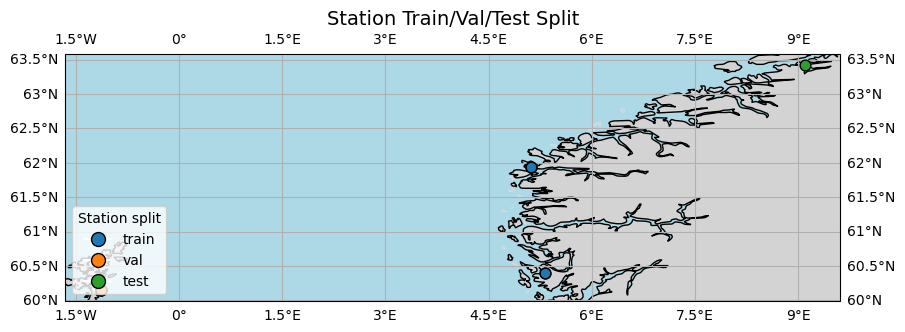

In [ ]:
# pip install cartopy matplotlib

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Station metadata from dataset
stations = ds["station"].values
lats = ds["station_latitude"].values
lons = ds["station_longitude"].values

# Assign split labels
split_labels = []
for st in stations:
    if st in train_stn:
        split_labels.append("train")
    elif st in val_stn:
        split_labels.append("val")
    elif st in test_stn:
        split_labels.append("test")
    else:
        split_labels.append("unknown")

# Map colors
colors = {"train": "tab:blue", "val": "tab:orange", "test": "tab:green", "unknown": "gray"}

# Plot
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.gridlines(draw_labels=True)

# Scatter stations
for lat, lon, label in zip(lats, lons, split_labels):
    ax.scatter(lon, lat, color=colors[label], s=60, edgecolor="k", transform=ccrs.PlateCarree(), zorder=5)

# Legend
handles = [plt.Line2D([0], [0], marker="o", color="w", label=lbl,
                      markerfacecolor=col, markersize=10, markeredgecolor="k")
           for lbl, col in colors.items() if lbl != "unknown"]
ax.legend(handles=handles, loc="lower left", title="Station split")

plt.title("Station Train/Val/Test Split", fontsize=14)
plt.show()
